____
# Spatial scales


In [1]:
import numpy as np
import pandas as pd
import xarray as xr

import matplotlib.pyplot as plt

import os
from glob import glob

from cstes import swot_dir, drifters_dir, get_proj, lonlat2xy, zarr_dir, surface_drifters, depth_drifters, depth_100, depth_50, images_dir, U2, err_acc
from diagnosis import update_dict, dataset_coloc_combs, dataset_coloc_combs, prepared_drifters, prepared_wd, prepared_alti, compute_mean_square, compute_mean_square_groupby, plot_error, extract_mean_geo

import cartopy.crs as ccrs
import cartopy.feature as cfeature
import cartopy.geodesic as cgeo
crs = ccrs.PlateCarree()

import cartopy.geodesic as geod
import cartopy.crs as ccrs
import cartopy.feature as cfeature

import pyproj
from pyproj import Geod

from rasterio.transform import Affine

import pynsitu as pyn

from diagnosis import synthetic_figure
from cstes import U2, c0

_______
# Data

In [2]:
dt=12
distance_to_coast_max = 20e3
alti_product_key='swot2km'
drifter_preprocess = ''
drifter_preprocess_param=''
max_ggd = 1e-4
from diagnosis import define_coloc_source
colocs_sources = define_coloc_source('12h', drifter_preprocess, drifter_preprocess_param)

In [6]:
dd = pd.read_csv('/home/datawork-lops-oc/aponte/margot/DATA_MED_COLOC/coloc_files/alti/alticoloc_swot2km_gaussian_30000_12h_spectral_decomp_all_med_variational_10min_v0.csv')

In [7]:
dd

,row_number,cycle_number,longitude,latitude,filtered_etaf,dx_etaf,dy_etaf,dxx_etaf,dyy_etaf,dxy_etaf,filtered_etac,dx_etac,dy_etac,dxx_etac,dyy_etac,dxy_etac,cutoff,pass_number
0,0,478,4.811970,42.220893,-0.119658,-3.818382e-07,2.957026e-07,-1.112189e-11,2.537796e-13,-2.770837e-12,-0.118666,-3.797185e-07,2.870079e-07,-1.193478e-11,-5.275550e-13,-3.014626e-12,30000,3
1,1,478,4.812432,42.221430,-0.119653,-3.834356e-07,2.955069e-07,-1.110355e-11,1.811712e-13,-2.788202e-12,-0.118662,-3.814451e-07,2.866684e-07,-1.191675e-11,-6.039513e-13,-3.031043e-12,30000,3
2,2,478,4.812916,42.221930,-0.119638,-3.836389e-07,2.954977e-07,-1.109307e-11,1.675027e-13,-2.801497e-12,-0.118648,-3.816655e-07,2.866147e-07,-1.190502e-11,-6.182775e-13,-3.044866e-12,30000,3
3,3,478,4.813418,42.222394,-0.119624,-3.838790e-07,2.954791e-07,-1.108282e-11,1.526200e-13,-2.814729e-12,-0.118634,-3.819253e-07,2.865493e-07,-1.189360e-11,-6.338727e-13,-3.058580e-12,30000,3
4,4,478,4.813933,42.222825,-0.119610,-3.841517e-07,2.954519e-07,-1.107281e-11,1.366633e-13,-2.827868e-12,-0.118621,-3.822202e-07,2.864732e-07,-1.188250e-11,-6.505895e-13,-3.072156e-12,30000,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
374705,376718,577,2.417786,39.788394,0.021831,2.305288e-07,5.783223e-07,1.468208e-11,3.624421e-11,5.704047e-13,-0.116273,3.897492e-06,-3.966457e-06,2.335406e-11,1.255200e-10,1.316057e-10,30000,16
374706,376719,577,2.416881,39.788885,0.021808,2.311431e-07,5.762624e-07,1.472634e-11,3.617664e-11,5.578175e-13,-0.115863,3.890814e-06,-3.967279e-06,2.329236e-11,1.239867e-10,1.316753e-10,30000,16
374707,376720,577,2.415948,39.789399,0.021777,2.317127e-07,5.737503e-07,1.477571e-11,3.609695e-11,5.487840e-13,-0.115416,3.882403e-06,-3.969910e-06,2.324540e-11,1.221578e-10,1.317678e-10,30000,16
374708,376721,577,2.414994,39.789938,0.021738,2.322589e-07,5.707056e-07,1.483195e-11,3.600264e-11,5.430197e-13,-0.114916,3.871992e-06,-3.974409e-06,2.321147e-11,1.199749e-10,1.318863e-10,30000,16


_______
# Gaussian

In [8]:
#GAUSSIAN
cutoff = np.arange(5e3, 60e3, 5e3)

# SURFACE
base_dic = dict(dt='12h', 
        drifter_preprocess = drifter_preprocess,
        drifter_preprocess_param=drifter_preprocess_param,
        alti_product_key= alti_product_key,
        alti_diff_method = 'gaussian',
        alti_diff_method_param = '',
        ggd_var = 'etaf',
        wd_product_key = 'era5', 
        wd_model ='rio', 
        wd_depth = '0')

comb_list = [update_dict(base_dic, dict(alti_diff_method_param = int(ct))) for ct in cutoff]

ds0 = dataset_coloc_combs(comb_list, nearest =False, remove_id_outliers = True)
ds0['comb'] = ds0['id_comb']
ds0['id_comb'] = ('id_comb',cutoff)
distance_to_coast = ds0.distance_to_coast.isel(id_comb = 0)
ds0['distance_to_coast'] = ('row_number', distance_to_coast.values)

#DEPTH 15M
base_dic = update_dict(base_dic, dict(wd_depth = '15'))
comb_list = [update_dict(base_dic, dict(alti_diff_method_param = int(ct))) for ct in cutoff]

ds15 = dataset_coloc_combs(comb_list, nearest =False, remove_id_outliers = True)
ds15['comb'] = ds15['id_comb']
ds15['id_comb'] = ('id_comb',cutoff)
distance_to_coast = ds15.distance_to_coast.isel(id_comb = 0)
ds15['distance_to_coast'] = ('row_number', distance_to_coast.values)

DS = xr.concat([ds0.where(ds0.depth==0, drop=True), ds15.where(ds15.depth==15, drop=True)], dim='row_number')
DS = DS.where(DS.time_to_swot/pd.Timedelta('1h')<dt).dropna('row_number')
#DS = DS.where((abs(DS.ggde)<max_ggd) & (abs(DS.ggdn)<max_ggd), drop=True)
DSG = DS.where(DS.distance_to_coast>distance_to_coast_max, drop=True)

DSG = extract_mean_geo(DSG)

DSG = DSG.rename({'id_comb':'cutoff'})
DSG['cutoff'] = DSG.cutoff/1000
DSG['cutoff'] = DSG['cutoff'].assign_attrs({'long_name': 'Gaussian filter cutoff', 'units':'km'})

# Closure figs
dsg = compute_mean_square(DSG)/U2



Index(['cycle_number', 'longitude', 'latitude',
       'ancillary_surface_classification_flag', 'cross_track_distance',
       'distance_to_coast', 'duacs_editing_flag', 'duacs_phase_screen',
       'duacs_phase_screen_orbit', 'duacs_phase_screen_static',
       'duacs_relative_vorticity', 'duacs_speed_meridional',
       'duacs_speed_meridional_abs', 'duacs_speed_zonal',
       'duacs_speed_zonal_abs', 'duacs_strain', 'duacs_xcal', 'sig0_karin_2',
       'swh_model', 'ssh_karin_uncert', 'phi', 'dx', 'dy', 'pass_number', 'f',
       'cycle_number', 'longitude', 'latitude', 'filtered_etaf', 'dx_etaf',
       'dy_etaf', 'dxx_etaf', 'dyy_etaf', 'dxy_etaf', 'filtered_etac',
       'dx_etac', 'dy_etac', 'dxx_etac', 'dyy_etac', 'dxy_etac', 'cutoff',
       'pass_number', 'ggde_fromduacsv', 'ggdn_fromduacsv'],
      dtype='object')
['etaf', 'etac']
313260
12h_spectral_decomp_all_med_variational_10min_v0____swot2km_gaussian_5000_etaf__era5_rio0
Index(['cycle_number', 'longitude', 'latitude',
 

In [6]:
dsg.to_netcdf(os.path.join(zarr_dir, 'diag_files', f'gaussian_{colocs_sources}.nc'))

/home1/datahome/mdemol/.miniconda3/envs/histenv/lib/python3.9/site-packages/dask/config.py:742: FutureWarning: Dask configuration key 'distributed.scheduler.transition-log-length' has been deprecated; please use 'distributed.admin.low-level-log-length' instead
  warnings.warn(
/home1/datahome/mdemol/.miniconda3/envs/histenv/lib/python3.9/site-packages/dask/config.py:742: FutureWarning: Dask configuration key 'distributed.comm.recent-messages-log-length' has been deprecated; please use 'distributed.admin.low-level-log-length' instead
  warnings.warn(


In [3]:
dsg = xr.open_dataset(os.path.join(zarr_dir, 'diag_files', f'gaussian_{colocs_sources}.nc'))

In [5]:
# SURFACE
base_dic = dict(dt='12h', 
        drifter_preprocess = drifter_preprocess,
        drifter_preprocess_param=drifter_preprocess_param,
        alti_product_key=alti_product_key,
        alti_diff_method = 'fromduacsv',
        alti_diff_method_param = '',
        ggd_var = 'fromduacsv',
        wd_product_key = 'era5', 
        wd_model ='rio', 
        wd_depth = '0')

comb_list = [base_dic, 
             update_dict(base_dic, {'alti_product_key':'L4_noswot_regional'}),
             update_dict(base_dic, {'alti_product_key':'L4_noswot_global'}),
             update_dict(base_dic, {'alti_product_key':'L4_withnadirswot'}),    
]

l = ['L3-SWOT 2km', 'L4_noswot_regional', 'L4_noswot_global', 'L4_withnadirswot']

ds0 = dataset_coloc_combs(comb_list, nearest =False, remove_id_outliers = True)
ds0['comb'] = ds0['id_comb']
ds0['id_comb'] = ('id_comb',l)
distance_to_coast = ds0.distance_to_coast.isel(id_comb = 0)
ds0['distance_to_coast'] = ('row_number', distance_to_coast.values)

#DEPTH 15M
comb_list = [update_dict(c, dict(wd_depth='15')) for c in comb_list]

ds15 = dataset_coloc_combs(comb_list, nearest =False, remove_id_outliers = True)
ds15['comb'] = ds15['id_comb']
ds15['id_comb'] = ('id_comb',l)
distance_to_coast = ds15.distance_to_coast.isel(id_comb = 0)
ds15['distance_to_coast'] = ('row_number', distance_to_coast.values)

DS = xr.concat([ds0.where(ds0.depth==0, drop=True), ds15.where(ds15.depth==15, drop=True)], dim='row_number')
DS = DS.where(DS.time_to_swot/pd.Timedelta('1h')<dt).dropna('row_number')
DS = DS.where((abs(DS.ggde)<max_ggd) & (abs(DS.ggdn)<max_ggd), drop=True)
DS4 = DS.where(DS.distance_to_coast>distance_to_coast_max, drop=True)

DS4 = extract_mean_geo(DS4)

DS4 = DS4.rename({'id_comb':'altiprod'})
DS4['altiprod'] = DS4['altiprod'].assign_attrs({'long_name': 'Altimetric products'})

# Closure figs
ds4 = compute_mean_square(DS4)/U2

307771
12h_spectral_decomp_all_med_variational_10min_v0____swot2km_fromduacsv__fromduacsv__era5_rio0
only 'fromduacsv' method is available for L4
365891
12h_spectral_decomp_all_med_variational_10min_v0____L4_noswot_regional_fromduacsv__fromduacsv__era5_rio0
only 'fromduacsv' method is available for L4
368591
12h_spectral_decomp_all_med_variational_10min_v0____L4_noswot_global_fromduacsv__fromduacsv__era5_rio0
only 'fromduacsv' method is available for L4
373036
12h_spectral_decomp_all_med_variational_10min_v0____L4_withnadirswot_fromduacsv__fromduacsv__era5_rio0
Identified SWOT and drifter outliers have been removed
307771
12h_spectral_decomp_all_med_variational_10min_v0____swot2km_fromduacsv__fromduacsv__era5_rio15
only 'fromduacsv' method is available for L4
365891
12h_spectral_decomp_all_med_variational_10min_v0____L4_noswot_regional_fromduacsv__fromduacsv__era5_rio15
only 'fromduacsv' method is available for L4
368591
12h_spectral_decomp_all_med_variational_10min_v0____L4_noswot_glo

In [6]:
DS4['altiprod'] = ['L3-2km', 'L4-regional', 'L4-global', 'L4-SWOT-nadir']
ds4 = compute_mean_square(DS4)/U2

ok
geostrophic mean corrections


# Diagnoses

In [155]:
norm = -sum(np.arange(0, 9)*[1/280, -4/105, 1/5, 4/5, 0, -4/5, -1/5, 4/105, -1/280])
coef = (9.81/2e3/norm)**2 * 2*((1/280)**2 + (4/105)**2 + (1/5)**2+(4/5)**2)

sig3km1 = 0.4e-2#chelton 2024
sig3km2 = 0.25e-2#chelton 2024

def varggd_from_sigmassh(sigmassh):
    return coef * sigmassh**2/U2

def sigmassh_from_varggd(sigmaggd):
    return np.sqrt(sigmaggd*U2/coef)


def sigmassh(cutoff, sig3km=sig3km1):#cutoff en km, 
    return sig3km/0.4 * 2.401/cutoff# sigmassh en m


def neg_pow_fit(cutoff, coef, power, a):
    return coef/(cutoff**power)
    
def exp_fit(cutoff, a, b):
    return a*np.exp(-cutoff/b)
    
from scipy.optimize import curve_fit

cutoff = xr.DataArray(data = np.arange(0, 55, 1), 
                      dims=["cutoff"],
                      name='cutoff'
                     )

popt, pcov = curve_fit(neg_pow_fit, dsg.cutoff, dsg.E_ggd)
ig = xr.DataArray(neg_pow_fit(cutoff, *popt), coords={'cutoff':cutoff})

b_popt, b_pcov = curve_fit(neg_pow_fit, dsg.cutoff, dsg.B_ggd)
b_fit = xr.DataArray(neg_pow_fit(cutoff, *b_popt), coords={'cutoff':cutoff})

b_exp_popt, b_pcov = curve_fit(exp_fit, dsg.cutoff, dsg.B_ggd)
b_exp_fit = xr.DataArray(exp_fit(cutoff, *b_exp_popt), coords={'cutoff':cutoff})

e_exp_popt, e_pcov = curve_fit(exp_fit, [0] + list(dsg.cutoff), [ds4.isel(altiprod=0).E_ggd.values] + list(dsg.E_ggd))
e_exp_fit = xr.DataArray(exp_fit(cutoff, *e_exp_popt), coords={'cutoff':cutoff})

g_exp_popt, g_pcov = curve_fit(exp_fit, dsg.cutoff, dsg.GGD)
g_exp_fit = xr.DataArray(exp_fit(cutoff, *g_exp_popt), coords={'cutoff':cutoff})

# E_ggd
def exp_neg_pow(ct, a, b, c, d):
    return a*np.exp(-ct/b) -c/ct**d
    
e_popt, e_pcov = curve_fit(exp_neg_pow, dsg.cutoff, dsg.E_ggd)
e_fit = xr.DataArray(exp_neg_pow(cutoff, *e_popt), coords={'cutoff':cutoff})

ct = dsg.cutoff.values

/home1/datahome/mdemol/.miniconda3/envs/histenv/lib/python3.9/site-packages/scipy/optimize/_minpack_py.py:1010: OptimizeWarning: Covariance of the parameters could not be estimated
  warnings.warn('Covariance of the parameters could not be estimated',
/home1/datahome/mdemol/.miniconda3/envs/histenv/lib/python3.9/site-packages/xarray/core/computation.py:821: RuntimeWarning: divide by zero encountered in divide
  result_data = func(*input_data)
/home1/datahome/mdemol/.miniconda3/envs/histenv/lib/python3.9/site-packages/xarray/core/computation.py:821: RuntimeWarning: divide by zero encountered in divide
  result_data = func(*input_data)


# Gaussian
## Observed

/dev/shm/pbs.3064455.datarmor0/ipykernel_53098/979576388.py:31: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(a)


Text(0, 0.5, '[$\\gamma^2$]')

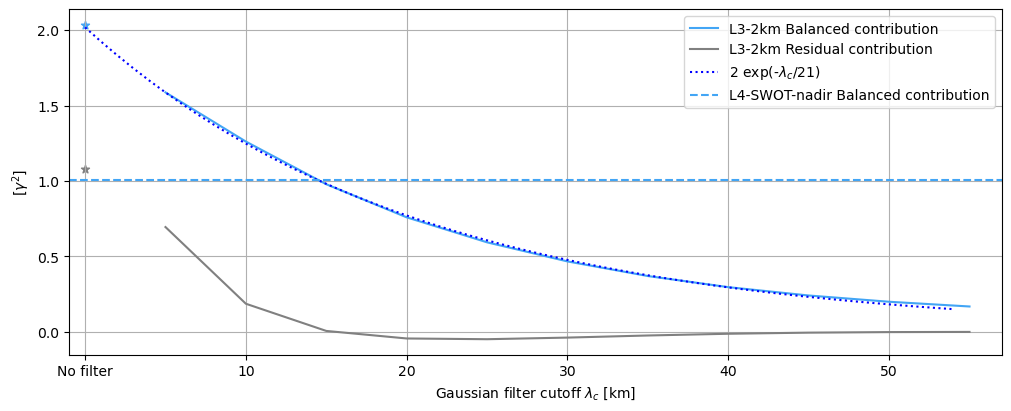

In [167]:
from matplotlib.gridspec import GridSpec
fig = plt.figure(layout="constrained", figsize = (10, 4))
gs = GridSpec(3, 3, figure=fig)

ax = fig.add_subplot(gs[:, :])
dsg.B_ggd.plot(ax=ax, label = 'L3-2km Balanced contribution', color=c0['ggd'])
dsg.E_ggd.plot(ax=ax, label = 'L3-2km Residual contribution', color='grey')
# Exponential fit
b_exp_fit.plot(ax=ax, ls=':', color = 'b', label = rf'{round(b_exp_popt[0])} exp(-$\lambda_c$/{round(b_exp_popt[1])})')
#e_exp_fit.plot(ax=ax, ls=':', color = 'b', label = rf'{round(e_exp_popt[0])} exp(-$\lambda_c$/{round(e_exp_popt[1])})')
# best fit but not exponenetial
#e_fit.sel(cutoff = slice(5, 55)).plot(ax=ax, ls=':',color = 'k', label = rf'{round(e_popt[0])} exp(-$\lambda_c$/{round(e_popt[1])}) - {round(e_popt[2])}/$\lambda_c^{round(e_popt[3])}$')

ax.scatter(0, ds4.isel(altiprod=0).B_ggd, marker = '*', c=c0['ggd'])
ax.scatter(0, ds4.isel(altiprod=0).E_ggd, marker = '*', c='grey')
#dsg.GGD.plot(ax=ax, label = 'MS')

for ap in ds4.altiprod.values[3:4]:
    ax.axhline(ds4.sel(altiprod=ap).B_ggd, ls='--',  color=c0['ggd'], label = ap + ' Balanced contribution')
    #ax.annotate(ap, (40,ds4.sel(altiprod=ap).B_ggd+0.02))
    #ax.axhline(ds4.sel(altiprod=ap.values).E_ggd, ls=':', color='orange')

    #ax.axhline(ds4.sel(altiprod=ap.values).GGD, ls=':', label=ap.values, color='orange')

ax.set_xlim(-1, 57)

a=ax.get_xticks().tolist()
a = [int(a_) for a_ in a]
a[1]='No filter'

ax.set_xticklabels(a)
ax.set_xlabel(r'Gaussian filter cutoff $\lambda_c$ [km]')
ax.grid()
ax.legend()
ax.set_ylabel(r'[$\gamma^2$]')

# Diverges when noise goes to 0
#ax2 = fig.add_subplot(gs[-1, :])
#abs(dsg.B_ggd/dsg.E_ggd).plot(ax=ax2, color='k')
#abs(b_exp_fit/e_fit).plot(ax=ax2, color='k', ls=':')
#ax2.grid()
#a=ax2.get_xticks().tolist()
#a[1]='No filter'
#ax2.set_xticklabels(a)
#ax2.set_ylabel('Balanced contribution\n over Residual contribution')
#ax2.set_xlabel(r'Gaussian filter cutoff $\lambda_c$ [km]')
#ax2.set_xlim(-1, 57)
#ax2.scatter(0, ds4.isel(altiprod=0).B_ggd/ds4.isel(altiprod=0).E_ggd, marker = '*', c='k')
#format_axes(fig)

Text(0, 0.5, '[$\\gamma^2$]')

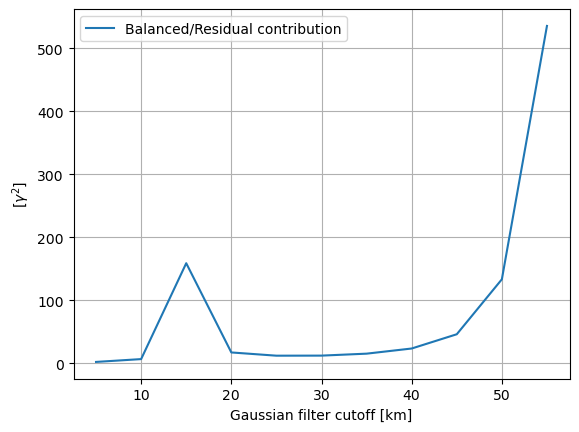

In [219]:
fig, ax = plt.subplots(1,1)
#ax = axs[0]
abs(dsg.B_ggd/dsg.E_ggd).plot(ax=ax, label = 'Balanced/Residual contribution')
ax.grid()
ax.legend()
ax.set_ylabel(r'[$\gamma^2$]')

# Theoritical -> not the good model 

In [158]:
dsms = xr.open_dataset(os.path.join(zarr_dir, 'diag_files', 'ms_noise_gaussian.nc'))
dsms['cutoff'] = dsms['cutoff']/1000

Text(0, 0.5, '[$\\gamma^2$]')

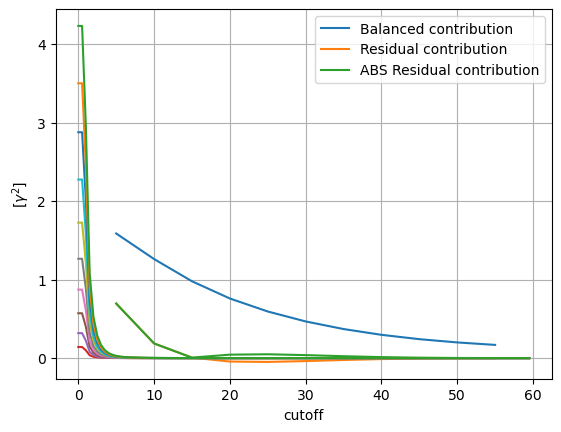

In [162]:
fig, ax = plt.subplots(1,1)
#ax = axs[0]
dsg.B_ggd.plot(ax=ax, label = 'Balanced contribution')
dsg.E_ggd.plot(ax=ax, label = 'Residual contribution')
abs(dsg.E_ggd).plot(ax=ax, label = 'ABS Residual contribution')
dsms.ms_noise_ggd.plot(hue='sigmassh', ax=ax)
#dsg.GGD.plot(ax=ax, label = 'MS')
#ax.plot(ct, varggd_from_sigmassh(sigmassh(ct, sig3km=sig3km1)), ls='--', label = 'sig3km = 0.4 cm')
#ax.plot(ct, varggd_from_sigmassh(sigmassh(ct, sig3km=sig3km2)), ls='--', label = 'sig3km = 0.25 cm')
#e_fit.plot(ls=':', label = rf'{np.round(e_popt[0])}exp(-{np.round(e_popt[1], 2)}$\lambda_c$) - {np.round(e_popt[2], 2)}/$\lambda_c$^{np.round(e_popt[3], 2)}')
#b_fit.plot(ls=':')
#b_exp_fit.plot(ls=':', label = rf'{np.round(b_exp_popt[0])}exp(-{np.round(b_exp_popt[1], 2)}$\lambda_c$)')
#g_exp_fit.plot(ls=':', label = rf'{np.round(g_exp_popt[0])}exp(-{np.round(g_exp_popt[1], 4)}*$\lambda_c$)')

ax.grid()
ax.legend()
ax.set_ylabel(r'[$\gamma^2$]')

## Other quantities

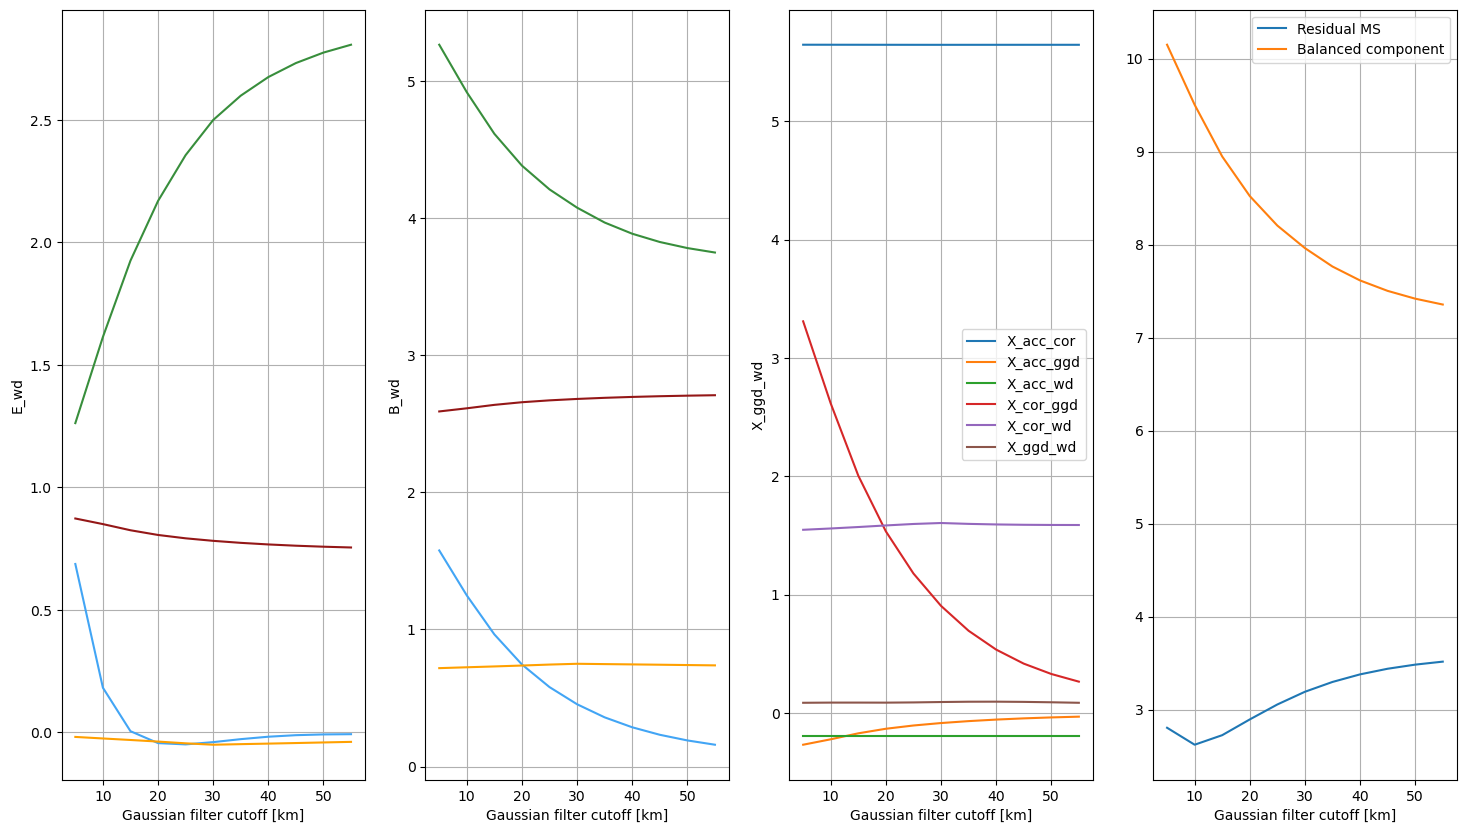

In [9]:
fig, axs = plt.subplots(1,4, figsize=(18, 10))
ax=axs[0]
for v in ['acc', 'ggd', 'cor', 'wd'] :
    dsg['E_'+v].plot(color=c0[v], ax=ax)
ax=axs[1]
for v in ['acc', 'ggd', 'cor', 'wd'] :
    dsg['B_'+v].plot(color=c0[v], ax=ax)
ax=axs[2]
for v in [v for v in dsg if ('X_' in v)&('ser__' not in v)]: 
    dsg[v].plot(label=v, ax=ax)
    ax.legend()

ax=axs[3]
dsg.S.plot( ax=ax, label='Residual MS') 
(sum([dsg['B_'+v] for v in ['acc', 'ggd', 'cor', 'wd']])).plot(ax=ax, label='Balanced component') 
ax.legend()

for ax in axs :
    ax.grid()

# Fitting kernel - Not working

In [5]:
#FITTING KERNEL
npts = np.arange(5, 19, 2)

# SURFACE
base_dic = dict(dt='12h', 
        drifter_preprocess = drifter_preprocess,
        drifter_preprocess_param=drifter_preprocess_param,
        alti_product_key=alti_product_key,
        alti_diff_method = 'fitting_kernel',
        alti_diff_method_param = '',
        ggd_var = 'etaf',
        wd_product_key = 'era5', 
        wd_model ='rio', 
        wd_depth = '0')

comb_list = [update_dict(base_dic, dict(alti_diff_method_param = int(npt))) for npt in npts]

ds0 = dataset_coloc_combs(comb_list, nearest =False, remove_id_outliers = True)
ds0['comb'] = ds0['id_comb']
ds0['id_comb'] = ('id_comb',npts)
distance_to_coast = ds0.distance_to_coast.isel(id_comb = 0)
ds0['distance_to_coast'] = ('row_number', distance_to_coast.values)

#DEPTH 15M
base_dic = update_dict(base_dic, dict(wd_depth = '15'))
comb_list = [update_dict(base_dic, dict(alti_diff_method_param = int(npt))) for npt in npts]

ds15 = dataset_coloc_combs(comb_list, nearest =False, remove_id_outliers = True)
ds15['comb'] = ds15['id_comb']
ds15['id_comb'] = ('id_comb',npts)
distance_to_coast = ds15.distance_to_coast.isel(id_comb = 0)
ds15['distance_to_coast'] = ('row_number', distance_to_coast.values)

DS = xr.concat([ds0.where(ds0.depth==0, drop=True), ds15.where(ds15.depth==15, drop=True)], dim='row_number')
DS = DS.where(DS.time_to_swot/pd.Timedelta('1h')<dt).dropna('row_number')
DS = DS.where((abs(DS.ggde)<max_ggd) & (abs(DS.ggdn)<max_ggd), drop=True)
DSF = DS.where(DS.distance_to_coast>distance_to_coast_max, drop=True)


DSF = DSF.rename({'id_comb':'npts'})
DSF['npts'] = DSF.npts
DSF['npts'] = DSF['npts'].assign_attrs({'long_name': 'Fitting kernel number of points', 'units':'npts'})


# Closure figs
dsf = compute_mean_square(DSF)/U2


289188
12h_spectral_decomp_all_med_variational_10min_v0____swot2km_fitting_kernel_5_etaf__era5_rio0
276889
12h_spectral_decomp_all_med_variational_10min_v0____swot2km_fitting_kernel_7_etaf__era5_rio0
264246
12h_spectral_decomp_all_med_variational_10min_v0____swot2km_fitting_kernel_9_etaf__era5_rio0
250794
12h_spectral_decomp_all_med_variational_10min_v0____swot2km_fitting_kernel_11_etaf__era5_rio0
237840
12h_spectral_decomp_all_med_variational_10min_v0____swot2km_fitting_kernel_13_etaf__era5_rio0
223946
12h_spectral_decomp_all_med_variational_10min_v0____swot2km_fitting_kernel_15_etaf__era5_rio0
210192
12h_spectral_decomp_all_med_variational_10min_v0____swot2km_fitting_kernel_17_etaf__era5_rio0
Identified SWOT and drifter outliers have been removed
289188
12h_spectral_decomp_all_med_variational_10min_v0____swot2km_fitting_kernel_5_etaf__era5_rio15
276889
12h_spectral_decomp_all_med_variational_10min_v0____swot2km_fitting_kernel_7_etaf__era5_rio15
264246
12h_spectral_decomp_all_med_vari

Text(0, 0.5, '[$\\gamma^2$]')

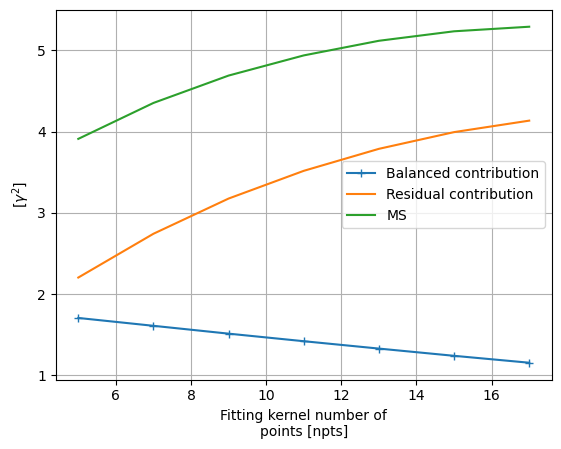

In [6]:
fig, ax = plt.subplots(1,1)
#ax = axs[0]
dsf.B_ggd.plot(ax=ax, label = 'Balanced contribution', marker='+')
dsf.E_ggd.plot(ax=ax, label = 'Residual contribution')
dsf.GGD.plot(ax=ax, label = 'MS')

ax.grid()
ax.legend()
ax.set_ylabel(r'[$\gamma^2$]')